# Breast Cancer Survival Prediction

## Exploratory Data Analysis (EDA)

This notebook explores the breast cancer survival dataset to understand data quality, feature distributions, and relationships between clinical variables and survival outcomes.

In [ ]:
# Imports

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
# Load dataset

df = pd.read_csv("../data/raw/breast_cancer.csv")

df.head()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Regional Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


## Dataset Overview

In [19]:
print("Shape:", df.shape)

df.info()

Shape: (4024, 16)
<class 'pandas.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Age                     4024 non-null   int64
 1   Race                    4024 non-null   str  
 2   Marital Status          4024 non-null   str  
 3   T Stage                 4024 non-null   str  
 4   N Stage                 4024 non-null   str  
 5   6th Stage               4024 non-null   str  
 6   differentiate           4024 non-null   str  
 7   Grade                   4024 non-null   str  
 8   A Stage                 4024 non-null   str  
 9   Tumor Size              4024 non-null   int64
 10  Estrogen Status         4024 non-null   str  
 11  Progesterone Status     4024 non-null   str  
 12  Regional Node Examined  4024 non-null   int64
 13  Regional Node Positive  4024 non-null   int64
 14  Survival Months         4024 non-null   int64
 15  Status        

In [20]:
df.describe()

,Age,Tumor Size,Regional Node Examined,Regional Node Positive,Survival Months
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,30.473658,14.357107,4.158052,71.297962
std,8.963134,21.119696,8.099675,5.109331,22.921430
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


## Missing Values Analysis

In [21]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

## Target Variable Distribution

In [22]:
df["Status"].value_counts()

Status
Alive    3408
Dead      616
Name: count, dtype: int64

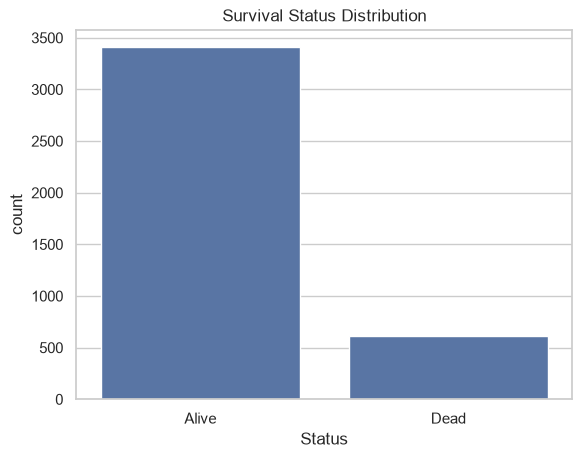

In [23]:
sns.countplot(data=df, x="Status")

plt.title("Survival Status Distribution")
plt.show()

## Numerical Features Analysis

In [24]:
numerical_columns = df.select_dtypes(include=np.number).columns

numerical_columns

Index(['Age', 'Tumor Size', 'Regional Node Examined', 'Regional Node Positive',
       'Survival Months'],
      dtype='str')

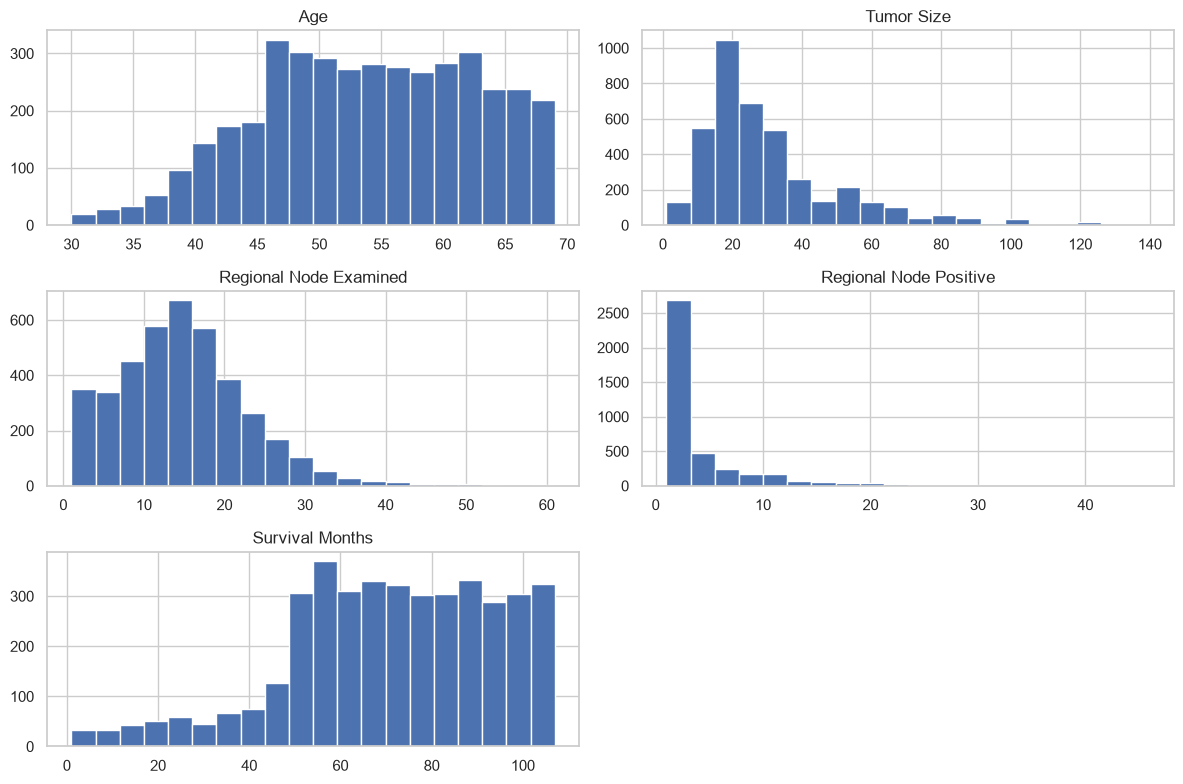

In [25]:
df[numerical_columns].hist(
    figsize=(12, 8),
    bins=20
)

plt.tight_layout()
plt.show()

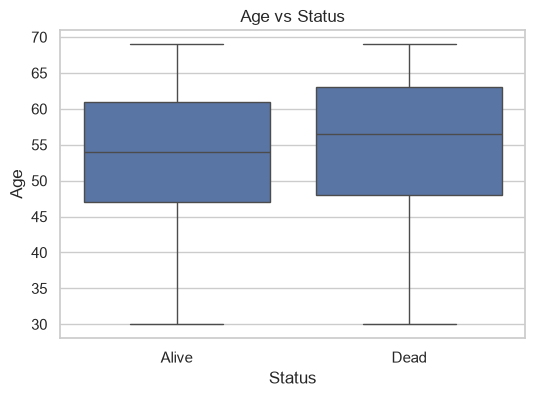

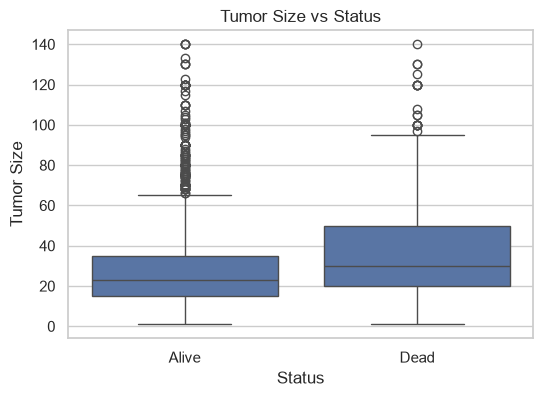

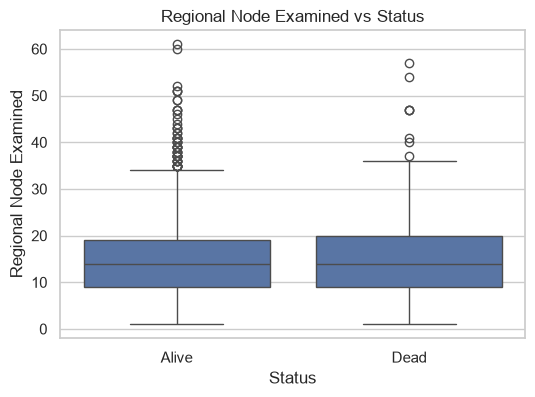

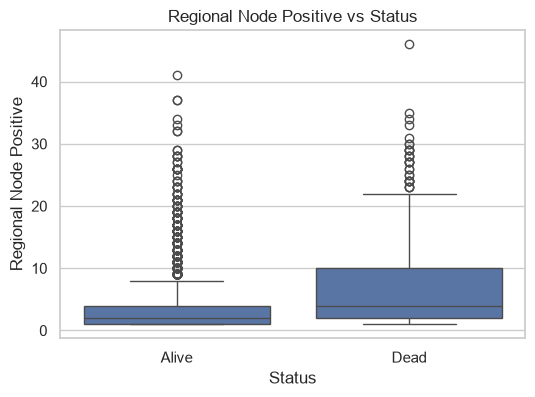

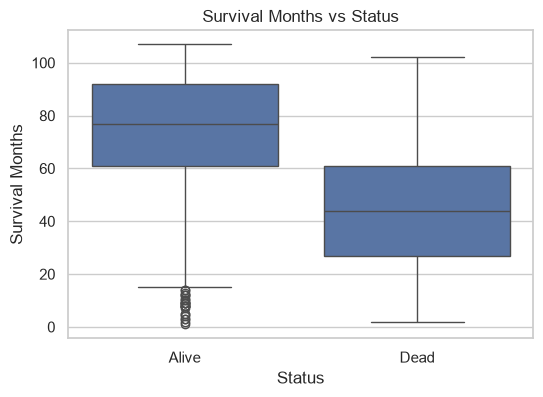

In [26]:
for col in numerical_columns:
    
    plt.figure(figsize=(6,4))
    
    sns.boxplot(
        data=df,
        x="Status",
        y=col
    )
    
    plt.title(f"{col} vs Status")
    plt.show()

## Categorical Features Analysis

In [30]:
categorical_columns = df.select_dtypes(include=str).columns

categorical_columns

Index(['Race', 'Marital Status', 'T Stage ', 'N Stage', '6th Stage',
       'differentiate', 'Grade', 'A Stage', 'Estrogen Status',
       'Progesterone Status', 'Status'],
      dtype='str')

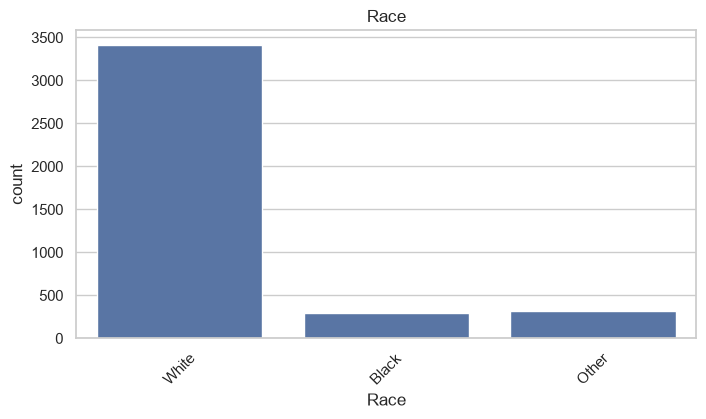

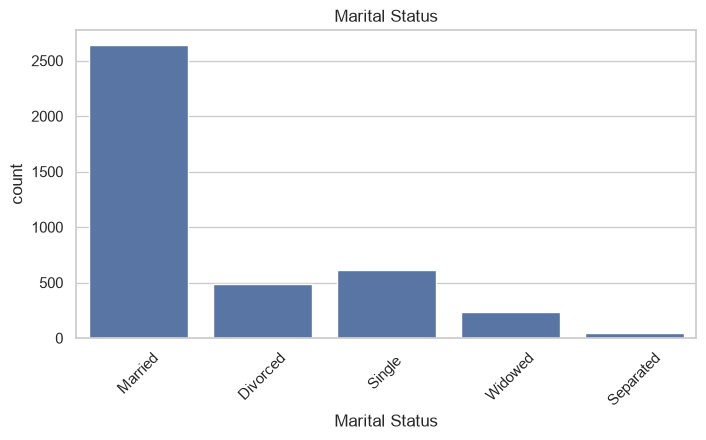

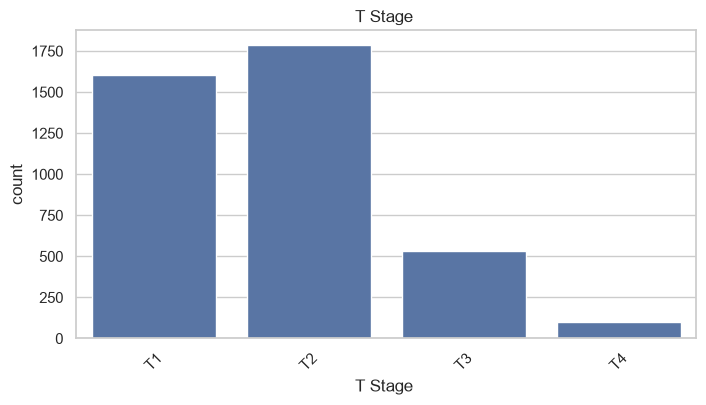

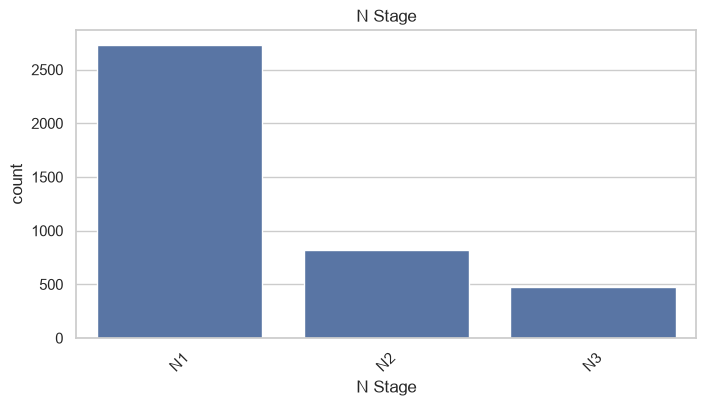

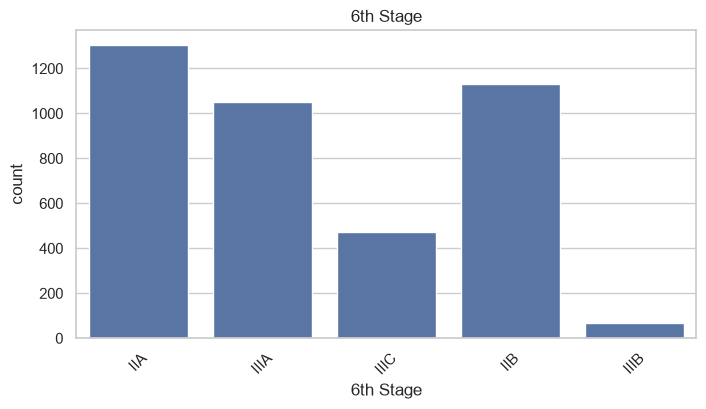

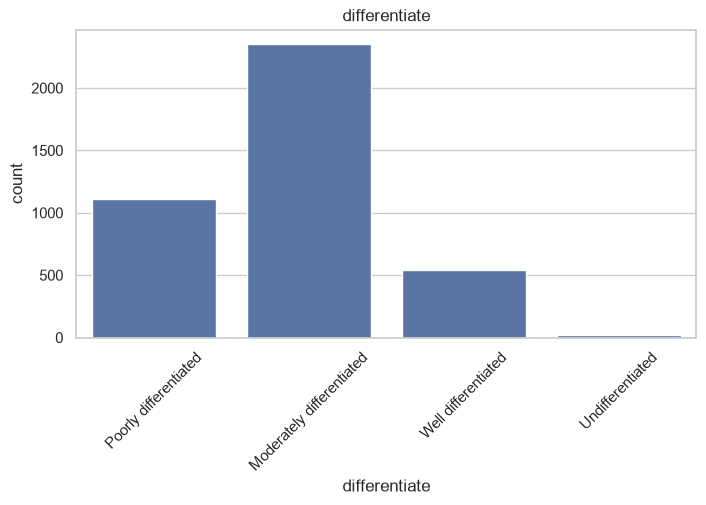

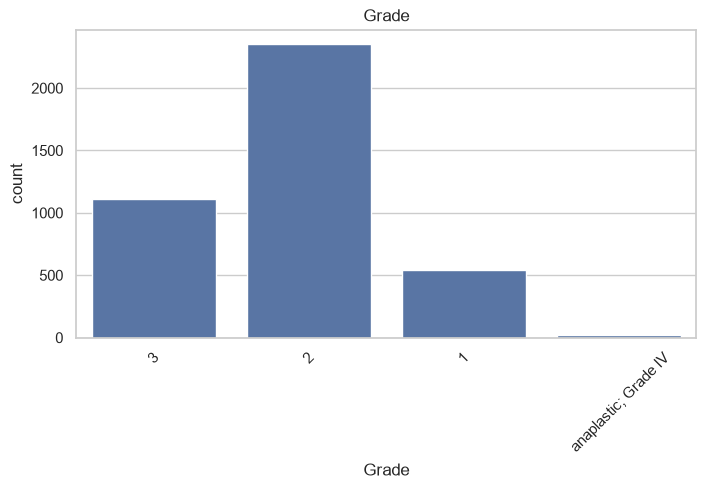

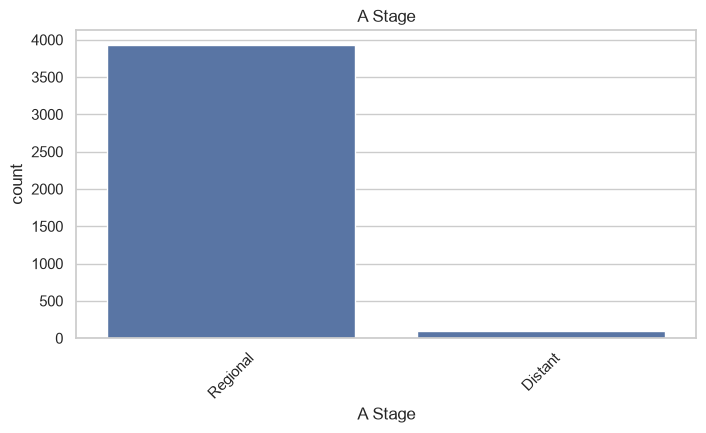

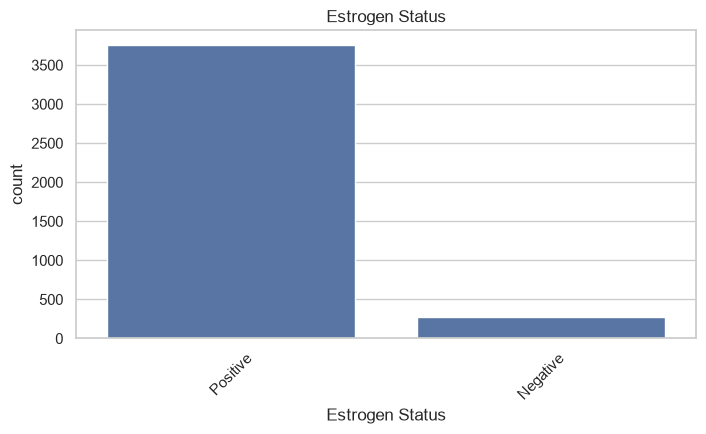

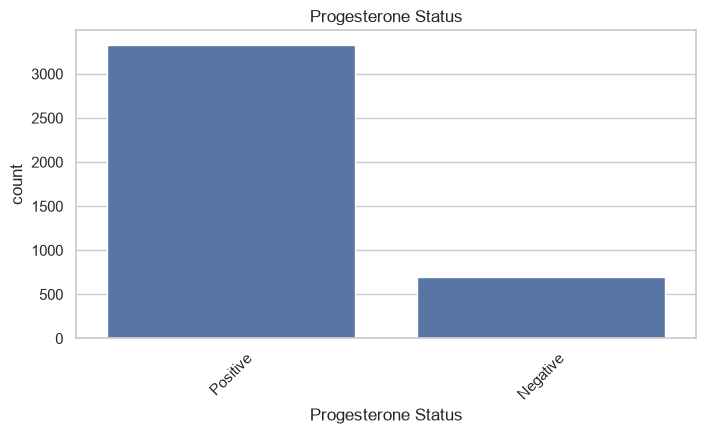

In [31]:
for col in categorical_columns:
    
    if col != "Status":
        
        plt.figure(figsize=(8,4))
        
        sns.countplot(
            data=df,
            x=col
        )
        
        plt.xticks(rotation=45)
        plt.title(col)
        
        plt.show()

## Correlation Analysis

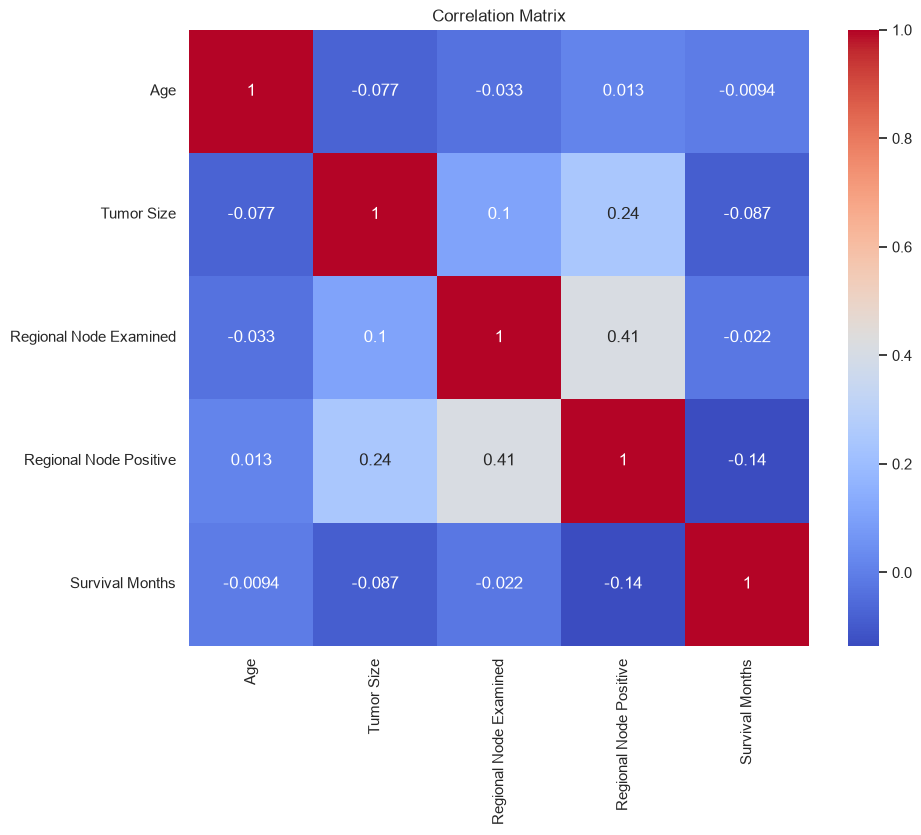

In [32]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

## Key Findings

